In [1]:
!pip install torchdiffeq

In [3]:
import torch
import torchvision
from torchdiffeq import odeint
from torch import nn
import numpy as np
from tqdm import tqdm
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [6]:
from einops import rearrange
class dfwrapper(nn.Module):
    def __init__(self, df, shape, recf=None):
        super(dfwrapper, self).__init__()
        self.df = df
        self.shape = shape
        self.recf = recf

    def forward(self, t, x):
        bsize = x.shape[0]
        if self.recf:
            x = x[:, :-self.recf.osize].reshape(bsize, *self.shape)
            dx = self.df(t, x)
            dr = self.recf(t, x, dx).reshape(bsize, -1)
            dx = dx.reshape(bsize, -1)
            dx = torch.cat([dx, dr], dim=1)
        else:
            x = x.reshape(bsize, *self.shape)
            dx = self.df(t, x)
            dx = dx.reshape(bsize, -1)
        return dx

class DF(nn.Module):

    def __init__(self, in_channels, nhid, out_channels=None):
        super(DF, self).__init__()
        if out_channels is None:
            out_channels = in_channels
        self.activation = nn.ReLU(inplace=True)
        self.fc1 = nn.Conv2d(in_channels + 1, nhid, kernel_size=1, padding=0)
        self.fc2 = nn.Conv2d(nhid + 1, nhid, kernel_size=3, padding=1)
        self.fc3 = nn.Conv2d(nhid + 1, out_channels, kernel_size=1, padding=0)

    def forward(self, t, x0):
        x0 = rearrange(x0, 'b d c x y -> b (d c) x y')
        t_img = torch.ones_like(x0[:, :1, :, :]).to(device) * t
        out = torch.cat([x0, t_img], dim=1)
        out = self.fc1(out)
        out = self.activation(out)
        out = torch.cat([out, t_img], dim=1)
        out = self.fc2(out)
        out = self.activation(out)
        out = torch.cat([out, t_img], dim=1)
        out = self.fc3(out)
        out = rearrange(out, 'b c x y -> b 1 c x y')
        return out

class NODE(nn.Module):
    def __init__(self, df=None, **kwargs):
        super(NODE, self).__init__()
        self.__dict__.update(kwargs)
        self.df = df
        self.nfe = 0
        self.elem_t = None

    def forward(self, t, x):
        self.nfe += 1
        if self.elem_t is None:
            return self.df(t, x)
        else:
            return self.elem_t * self.df(self.elem_t, x)

    def update(self, elem_t):
        self.elem_t = elem_t.view(*elem_t.shape, 1)

class NODEintegrate(nn.Module):

    def __init__(self, df, shape=None, tol=1e-5, adjoint=True, evaluation_times=None, recf=None, algebraic_from_differential=None, differential_from_algebraic=None, activation_h=None, activation_output=None, time_requires_grad=True, verbose=True):
        super().__init__()
        self.df = dfwrapper(df, shape, recf) if shape else df
        self.nesterov_factor = 3
        self.tol = tol
        if verbose:
            print(f"Tolerance: {self.tol}")
            print(f"Adjoint:", adjoint)
        self.odeint = torchdiffeq.odeint_adjoint if adjoint else torchdiffeq.odeint
        self.evaluation_times = evaluation_times if evaluation_times is not None else torch.Tensor([0.0, 1.0])
        if time_requires_grad == False:
            self.evaluation_times.requires_grad = False
        if verbose:
            print("Evaluation times:", self.evaluation_times)
            print("Learnable eval times:", self.evaluation_times.requires_grad)
        self.shape = shape
        self.recf = recf
        self.algebraic_from_differential = algebraic_from_differential
        self.activation_h = nn.Identity() if activation_h is None else activation_h
        self.activation_output = nn.Identity() if activation_output is None else activation_output
        if verbose:
            print("self.algebraic_from_differential:", self.algebraic_from_differential)
            print("self.activation_h for NODEintegrate:", self.activation_h)
        if recf:
            assert shape is not None
        self.differential_from_algebraic = differential_from_algebraic

    def forward(self, x0):
        if self.differential_from_algebraic:
            x, m = self.calc_differential_from_algebraic(x0, self.evaluation_times[0])
            x0 = torch.cat((x, m), dim=1)

        bsize = x0.shape[0]
        if self.shape:
            assert x0.shape[1:] == torch.Size(self.shape), \
                'Input shape {} does not match with model shape {}'.format(x0.shape[1:], self.shape)
            x0 = x0.reshape(bsize, -1)
            if self.recf:
                reczeros = torch.zeros_like(x0[:, :1])
                reczeros = repeat(reczeros, 'b 1 -> b c', c=self.recf.osize)
                x0 = torch.cat([x0, reczeros], dim=1)
            out = odeint(self.df, x0, self.evaluation_times, rtol=self.tol, atol=self.tol)
            if self.algebraic_from_differential:
                out = self.calc_algebraic_from_differential(out)
            if self.recf:
                rec = out[-1, :, -self.recf.osize:]
                out = out[:, :, :-self.recf.osize]
                out = out.reshape(-1, bsize, *self.shape)
                return out, rec
            else:
                return out
        else:
            out = odeint(self.df, x0, self.evaluation_times, rtol=self.tol, atol=self.tol)
            if self.algebraic_from_differential:
                out = self.calc_algebraic_from_differential(out)
            return out

    @property
    def nfe(self):
        return self.df.nfe

    def to(self, device, *args, **kwargs):
        super().to(device, *args, **kwargs)
        self.evaluation_times.to(device)

    def calc_algebraic_from_differential(self, z):
        z_0 = z[:1]
        z_T = z[1:]
        if len(self.evaluation_times.shape) == 2:
            T = self.evaluation_times[:, 1:]
        else:
            T = self.evaluation_times[1:]
        x, m = torch.split(z_T, 1, dim=2)
        k = torch.pow(T, -3/2) * torch.exp(T / 2)
        if z.is_cuda:
            k = k.to(z.get_device())
            T = T.to(z.get_device())
        k = self.activation_h(k)
        h = self.activation_output(bmul(k, x))
        dh = self.activation_output(bmul(k, m - bmul(3/2 * torch.pow(T, 1/2) * torch.exp(-T/2) - 1/2 * 1/k, h)))
        z_t = torch.cat((h, dh), dim=2)
        out = torch.cat((z_0, z_t), dim=0)
        return out

    def calc_differential_from_algebraic(self, z, t):
        h, dh = torch.split(z, 1, dim=1)
        k_reciprocal = 1 / (torch.pow(t, -self.nesterov_factor/2) * torch.exp(t/2))
        if z.is_cuda:
            k_reciprocal = k_reciprocal.to(z.get_device())
        m = (self.nesterov_factor/2 * (1/t) * k_reciprocal - 1/2 * k_reciprocal) * h \
                + k_reciprocal * dh
        x = h * k_reciprocal
        return x, m

    def trajectory(self, x, timesteps):
        integration_time = torch.linspace(0., 1., timesteps)
        return self.forward(x, eval_times=integration_time)


class NODElayer(NODEintegrate):
    def forward(self, x0):
        out = super(NODElayer, self).forward(x0)
        if isinstance(out, tuple):
            out, rec = out
            return out[-1], rec
        else:
            return out[-1]

class NesterovNODE(NODE):
    def __init__(self, df, actv_h=None, corr=-100, corrf=True, use_h=False, full_details=False, algebraic_from_differential=True, actv_m=None, actv_dm=None, actv_df=None, sign=1):
        super().__init__(df)
        self.corr = Parameter([corr], frozen=corrf)
        self.sp = nn.Softplus()
        self.sign = sign # Sign of df
        self.actv_h = nn.Identity() if actv_h is None else actv_h # Activation for dh, GNNODE only
        self.actv_m = nn.Identity() if actv_m is None else actv_m # Activation for dh, GNNODE only
        self.actv_dm = nn.Identity() if actv_dm is None else actv_dm # Activation for dh, GNNODE only
        self.actv_df = nn.Identity() if actv_df is None else actv_df # Activation for df, GNNODE only
        self.use_h = use_h
        self.full_details = full_details
        self.algebraic_from_differential = algebraic_from_differential

    def forward(self, t, z):
        """
        Compute [x' m'] with diff-alg nesterov parametrization in
        $$ h' = -m $$
        $$ m' = sign * df(t, h) - m - xi * h $$
        :param t: time, shape [1]
        :param z: [h dh], shape [batch, 2, dim]
        :return: [x' m'], shape [batch, 2, dim]
        """
        self.nfe += 1
        x, m = torch.split(z, 1, dim=1)
        dx = self.actv_h(m)
        k = torch.pow(t, -3/2) * torch.exp(t/2)
        h = x * self.actv_h(k)
        dm = self.actv_df(self.df(t, h)) * self.sign - m
        dm = self.actv_dm(self.actv_m(dm) - self.sp(self.corr()) * h)
        out = torch.cat((dx, dm), dim=1)
        if self.elem_t is None:
            return out
        else:
            return self.elem_t * out

    def update(self, elem_t):
        self.elem_t = elem_t.view(*elem_t.shape, 1, 1)

class Parameter(nn.Module):
    def __init__(self, val, frozen=False):
        super().__init__()
        val = torch.Tensor(val)
        self.val = val
        self.param = nn.Parameter(val)
        self.frozen = frozen

    def forward(self):
        if self.frozen:
            self.val = self.val.to(self.param.device)
            return self.val
        else:
            return self.param

    def freeze(self):
        self.val = self.param.detach().clone()
        self.frozen = True

    def unfreeze(self):
        self.frozen = False

    def __repr__(self):
        return "val: {}, param: {}".format(self.val.cpu(), self.param.detach().cpu())


class hbnode_initial_velocity(nn.Module):

    def __init__(self, in_channels, out_channels, nhid):
        super(hbnode_initial_velocity, self).__init__()
        assert (3 * out_channels >= in_channels)
        self.actv = nn.LeakyReLU(0.3)
        self.fc1 = nn.Conv2d(in_channels, nhid, kernel_size=1, padding=0)
        self.fc2 = nn.Conv2d(nhid, nhid, kernel_size=3, padding=1)
        self.fc3 = nn.Conv2d(nhid, 2 * out_channels - in_channels, kernel_size=1, padding=0)
        self.out_channels = out_channels
        self.in_channels = in_channels

    def forward(self, x0):
        x0 = x0.float()
        out = self.fc1(x0)
        out = self.actv(out)
        out = self.fc2(out)
        out = self.actv(out)
        out = self.fc3(out)
        out = torch.cat([x0, out], dim=1)
        out = rearrange(out, 'b (d c) ... -> b d c ...', d=2)
        return out

class predictionlayer(nn.Module):
    def __init__(self, in_channels, truncate=False, dropout=0.0):
        super(predictionlayer, self).__init__()
        self.dense = nn.Linear(in_channels * 28 * 28, 10)
        self.truncate = truncate
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        if self.truncate:
            x = rearrange(x[:, 0], 'b ... -> b (...)')
        else:
            x = rearrange(x, 'b ... -> b (...)')
        x = self.dropout(x)
        x = self.dense(x)
        return x

def bmul(vec, mat, axis=0):
    mat = mat.transpose(axis, -1)
    return (mat * vec.expand_as(mat)).transpose(axis, -1)

class anode_initial_velocity(nn.Module):

    def __init__(self, in_channels, aug, dch=1):
        super(anode_initial_velocity, self).__init__()
        self.aug = aug
        self.in_channels = in_channels
        self.dch = dch

    def forward(self, x0):
        outshape = list(x0.shape)
        outshape[1] = self.aug * self.dch
        out = torch.zeros(outshape).to(device)
        out[:, :1] += x0
        out = rearrange(out, 'b (d c) ... -> b d c ...', d=self.dch)
        return out

In [62]:
import torchdiffeq

# Node
# dim = 1
# nhid = 92
# evaluation_times = torch.Tensor([1, 2]).to(device)
# layer = NODElayer(NODE(DF(dim, nhid)),time_requires_grad=False, evaluation_times=evaluation_times)
# model = nn.Sequential(anode_initial_velocity(1, dim),
#                       layer, predictionlayer(dim))

# G nesterov Node
# dim = 5
# nhid = 50
# hard_tanh_half = nn.Hardtanh(-0.5, 0.5)
# evaluation_times = torch.Tensor([1, 2]).to(device)
# layer = NODElayer(NesterovNODE(DF(dim, nhid), actv_h=hard_tanh_half, actv_df=hard_tanh_half, corr=2.0, corrf=False, use_h=True, sign=-1), algebraic_from_differential=True, differential_from_algebraic=True, activation_h=hard_tanh_half, time_requires_grad=False, evaluation_times=evaluation_times)
# model = nn.Sequential(hbnode_initial_velocity(1, dim, nhid),
#                       layer, predictionlayer(dim, truncate=True))

# Nest
dim = 5
nhid = 50
evaluation_times = torch.Tensor([1, 2]).to(device)
layer = NODElayer(NesterovNODE(DF(dim, nhid), None, use_h=True, sign=-1), algebraic_from_differential=True, differential_from_algebraic=True, time_requires_grad=False, evaluation_times=evaluation_times)
model = nn.Sequential(hbnode_initial_velocity(1, dim, nhid),
                      layer, predictionlayer(dim, truncate=True))
model.to(device)

Tolerance: 1e-05
Adjoint: True
Evaluation times: tensor([1., 2.], device='cuda:0')
Learnable eval times: False
self.algebraic_from_differential: True
self.activation_h for NODEintegrate: Identity()


Sequential(
  (0): hbnode_initial_velocity(
    (actv): LeakyReLU(negative_slope=0.3)
    (fc1): Conv2d(1, 50, kernel_size=(1, 1), stride=(1, 1))
    (fc2): Conv2d(50, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fc3): Conv2d(50, 9, kernel_size=(1, 1), stride=(1, 1))
  )
  (1): NODElayer(
    (df): NesterovNODE(
      (df): DF(
        (activation): ReLU(inplace=True)
        (fc1): Conv2d(6, 50, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(51, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (fc3): Conv2d(51, 5, kernel_size=(1, 1), stride=(1, 1))
      )
      (corr): val: tensor([-100.]), param: tensor([-100.])
      (sp): Softplus(beta=1, threshold=20)
      (actv_h): Identity()
      (actv_m): Identity()
      (actv_dm): Identity()
      (actv_df): Identity()
    )
    (activation_h): Identity()
    (activation_output): Identity()
  )
  (2): predictionlayer(
    (dense): Linear(in_features=3920, out_features=10, bias=True)
    (dropout): Dro

In [63]:
from einops import rearrange

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()
num_epochs = 20
nfe_arr = np.zeros(num_epochs)
forward_nfe_arr = np.zeros(num_epochs)
NFEs = []
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(0, num_epochs):
    # Training
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)  # CrossEntropyLoss expects class indices, not one-hot

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track statistics
        train_loss_sum += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Calculate epoch statistics
    train_loss = train_loss_sum / len(train_loader.dataset)
    train_accuracy = 100.0 * train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Epoch: {epoch}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # Testing
    model.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():  # No need to track gradients during evaluation
        for images, labels in tqdm(test_loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss_sum += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_loss_sum / len(test_loader.dataset)
    test_accuracy = 100.0 * test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Epoch: {epoch}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")
    print("NFEs1: " + str(model[1].nfe))
    print("NFEs2: " + str(model[1].df.nfe))
    print("NFEs3: " + str(layer.nfe))
    NFEs.append(layer.nfe)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

100%|████████████████████████████████████████████████████████████████████| 469/469 [00:56<00:00,  8.31it/s]


Epoch: 0, Train Loss: 0.3002, Train Accuracy: 91.16%


100%|██████████████████████████████████████████████████████████████████████| 79/79 [00:04<00:00, 18.12it/s]


Epoch: 0, Test Loss: 0.1174, Test Accuracy: 96.68%
NFEs1: 15958
NFEs2: 15958
NFEs3: 15958


100%|████████████████████████████████████████████████████████████████████| 469/469 [01:02<00:00,  7.47it/s]


...

Epoch: 18, Test Loss: 0.1069, Test Accuracy: 98.12%
NFEs1: 443176
NFEs2: 443176
NFEs3: 443176


100%|████████████████████████████████████████████████████████████████████| 469/469 [01:36<00:00,  4.88it/s]


Epoch: 19, Train Loss: 0.0078, Train Accuracy: 99.73%


100%|██████████████████████████████████████████████████████████████████████| 79/79 [00:06<00:00, 11.97it/s]

Epoch: 19, Test Loss: 0.1185, Test Accuracy: 98.13%
NFEs1: 470600
NFEs2: 470600
NFEs3: 470600


In [10]:
import gc
torch.cuda.empty_cache()
gc.collect()

8

100%|██████████| 469/469 [04:23<00:00,  1.78it/s]
Epoch: 2, Train Loss: 0.3917, Train Accuracy: 88.30%
100%|██████████| 79/79 [00:16<00:00,  4.65it/s]
Epoch: 2, Test Loss: 0.2840, Test Accuracy: 91.54%
NFEs: 18856
100%|██████████| 469/469 [04:58<00:00,  1.57it/s]
Epoch: 3, Train Loss: 0.2856, Train Accuracy: 91.83%
100%|██████████| 79/79 [00:16<00:00,  4.66it/s]
Epoch: 3, Test Loss: 0.2612, Test Accuracy: 92.51%
NFEs: 40022
  7%|▋         | 33/469 [00:22<05:00,  1.45it/s]

In [11]:
model[1].nfe

1563

In [13]:
model[1].df.nfe

0

In [16]:
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, 'node_checkpoint.pth')

In [65]:
NFEs_nest = NFEs
train_losses_nest = train_losses
train_accuracies_nest = train_accuracies
test_losses_nest = test_losses
test_accuracies_nest = test_accuracies

In [69]:
import matplotlib.pyplot as plt

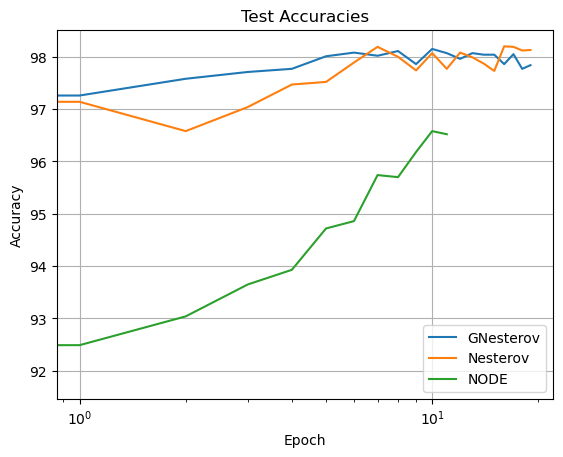

In [97]:
plt.plot(test_accuracies_g, label='GNesterov')
plt.plot(test_accuracies_nest, label='Nesterov')
plt.plot(test_accuracies_node, label='NODE')
plt.title("Test Accuracies")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xscale('log')
plt.legend()
plt.grid()

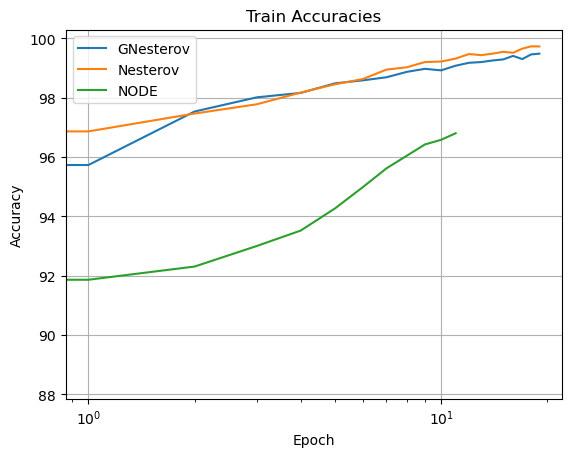

In [96]:
plt.plot(train_accuracies_g, label='GNesterov')
plt.plot(train_accuracies_nest, label='Nesterov')
plt.plot(train_accuracies_node, label='NODE')
plt.title("Train Accuracies")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xscale('log')
plt.legend()
plt.grid()

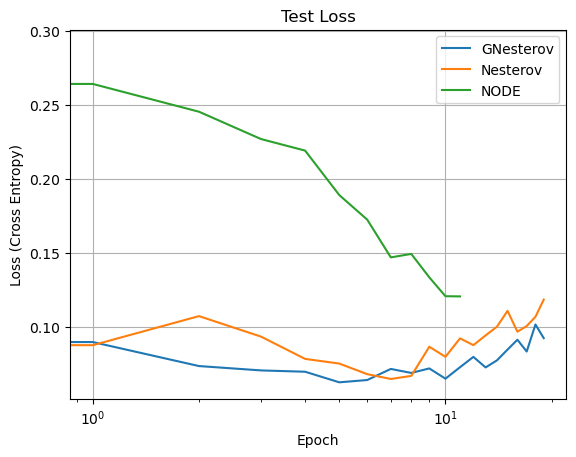

In [95]:
plt.plot(test_losses_g, label='GNesterov')
plt.plot(test_losses_nest, label='Nesterov')
plt.plot(test_losses_node, label='NODE')
plt.title("Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.xscale('log')
plt.legend()
plt.grid()

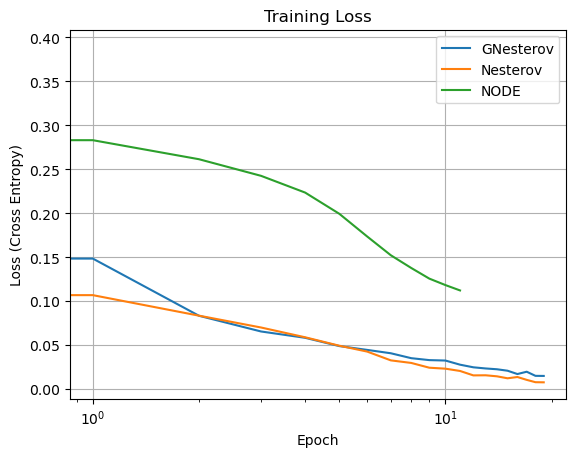

In [94]:
plt.plot(train_losses_g, label='GNesterov')
plt.plot(train_losses_nest, label='Nesterov')
plt.plot(train_losses_node, label='NODE')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.xscale('log')
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.grid()

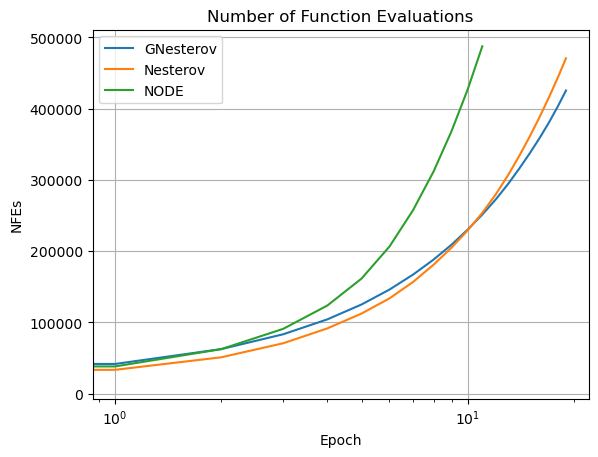

In [93]:
plt.plot(NFEs_g, label='GNesterov')
plt.plot(NFEs_nest, label='Nesterov')
plt.plot(NFEs_node, label='NODE')
plt.title("Number of Function Evaluations")
plt.xlabel("Epoch")
plt.xscale('log')
plt.ylabel("NFEs")
plt.legend()
plt.grid()